In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split  
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import sklearn.linear_model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC 




In [4]:
df = pd.read_csv(r"C:\Users\bahga\AppData\Local\Temp\9f016490-e84a-4c0a-86e8-4578ec4b478a_amazon.csv.zip.78a\amazon.csv")


print(df.columns)
for column in df.columns:
    print(column)

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='str')
product_id
product_name
category
discounted_price
actual_price
discount_percentage
rating
rating_count
about_product
user_id
user_name
review_id
review_title
review_content
img_link
product_link


In [5]:
print("dataset information")
df.info()

dataset information
<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   product_id           1465 non-null   str  
 1   product_name         1465 non-null   str  
 2   category             1465 non-null   str  
 3   discounted_price     1465 non-null   str  
 4   actual_price         1465 non-null   str  
 5   discount_percentage  1465 non-null   str  
 6   rating               1465 non-null   str  
 7   rating_count         1463 non-null   str  
 8   about_product        1465 non-null   str  
 9   user_id              1465 non-null   str  
 10  user_name            1465 non-null   str  
 11  review_id            1465 non-null   str  
 12  review_title         1465 non-null   str  
 13  review_content       1465 non-null   str  
 14  img_link             1465 non-null   str  
 15  product_link         1465 non-null   str  
dtypes: str(16)
memo

In [6]:


df.tail(5)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
1460,B08L7J3T31,Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...,Home&Kitchen|Kitchen&HomeAppliances|WaterPurif...,₹379,₹919,59%,4,"1,090",SUPREME QUALITY 90 GRAM 3 LAYER THIK PP SPUN F...,"AHITFY6AHALOFOHOZEOC6XBP4FEA,AFRABBODZJZQB6Z4U...","Prabha ds,Raghuram bk,Real Deal,Amazon Custome...","R3G3XFHPBFF0E8,R3C0BZCD32EIGW,R2EBVBCN9QPD9R,R...","Received the product without spanner,Excellent...","I received product without spanner,Excellent p...",https://m.media-amazon.com/images/I/41fDdRtjfx...,https://www.amazon.in/Noir-Aqua-Spanner-Purifi...
1461,B01M6453MB,Prestige Delight PRWO Electric Rice Cooker (1 ...,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,"₹2,280","₹3,045",25%,4.1,"4,118","230 Volts, 400 watts, 1 Year","AFG5FM3NEMOL6BNFRV2NK5FNJCHQ,AGEINTRN6Z563RMLH...","Manu Bhai,Naveenpittu,Evatira Sangma,JAGANNADH...","R3DDL2UPKQ2CK9,R2SYYU1OATVIU5,R1VM993161IYRW,R...","ok,everything was good couldn't return bcoz I ...","ok,got everything as mentioned but the measuri...",https://m.media-amazon.com/images/I/41gzDxk4+k...,https://www.amazon.in/Prestige-Delight-PRWO-1-...
1462,B009P2LIL4,Bajaj Majesty RX10 2000 Watts Heat Convector R...,"Home&Kitchen|Heating,Cooling&AirQuality|RoomHe...","₹2,219","₹3,080",28%,3.6,468,International design and styling|Two heat sett...,"AGVPWCMAHYQWJOQKMUJN4DW3KM5Q,AF4Q3E66MY4SR7YQZ...","Nehal Desai,Danish Parwez,Amazon Customer,Amaz...","R1TLRJVW4STY5I,R2O455KRN493R1,R3Q5MVGBRIAS2G,R...","very good,Work but front melt after 2 month,Go...","plastic but cool body ,u have to find sturdy s...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Bajaj-RX-10-2000-Watt-Co...
1463,B00J5DYCCA,Havells Ventil Air DSP 230mm Exhaust Fan (Pist...,"Home&Kitchen|Heating,Cooling&AirQuality|Fans|E...","₹1,399","₹1,890",26%,4,"8,031",Fan sweep area: 230 MM ; Noise level: (40 - 45...,"AF2JQCLSCY3QJATWUNNHUSVUPNQQ,AFDMLUXC5LS5RXDJS...","Shubham Dubey,E.GURUBARAN,Mayank S.,eusuf khan...","R39Q2Y79MM9SWK,R3079BG1NIH6MB,R29A31ZELTZNJM,R...","Fan Speed is slow,Good quality,Good product,go...",I have installed this in my kitchen working fi...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Havells-Ventilair-230mm-...
1464,B01486F4G6,Borosil Jumbo 1000-Watt Grill Sandwich Maker (...,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,"₹2,863","₹3,690",22%,4.3,"6,987","Brand-Borosil, Specification â€“ 23V ~ 5Hz;1 W...","AFGW5PT3R6ZAVQR4Y5MWVAKBZAYA,AG7QNJ2SCS5VS5VYY...","Rajib,Ajay B,Vikas Kahol,PARDEEP,Anindya Prama...","R20RBRZ0WEUJT9,ROKIFK9R2ISSE,R30EEG2FNJSN5I,R2...","Works perfect,Ok good product,Nice Product. Re...",It does it job perfectly..only issue is temp c...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Borosil-Jumbo-1000-Watt-...


In [7]:
df = pd.read_csv(r"C:\Users\bahga\AppData\Local\Temp\9f016490-e84a-4c0a-86e8-4578ec4b478a_amazon.csv.zip.78a\amazon.csv")
print("dataset shape:", df.shape)
print(df.head())

dataset shape: (1465, 16)
   product_id                                       product_name  \
0  B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1  B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2  B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3  B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4  B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   

                                            category discounted_price  \
0  Computers&Accessories|Accessories&Peripherals|...             ₹399   
1  Computers&Accessories|Accessories&Peripherals|...             ₹199   
2  Computers&Accessories|Accessories&Peripherals|...             ₹199   
3  Computers&Accessories|Accessories&Peripherals|...             ₹329   
4  Computers&Accessories|Accessories&Peripherals|...             ₹154   

  actual_price discount_percentage rating rating_count  \
0       ₹1,099                 64%    4.2       24,269   
1         

In [8]:
df = df[["review_content", "rating"]]
df = df.dropna(subset=["review_content"])

In [9]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

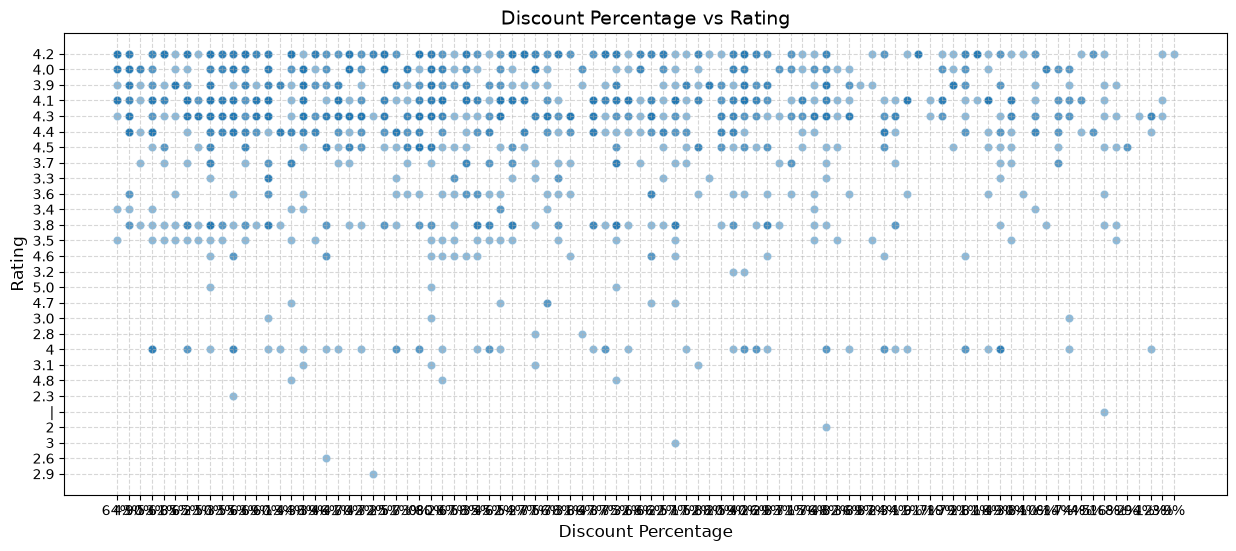

In [10]:
df = pd.read_csv(r"C:\Users\bahga\AppData\Local\Temp\9f016490-e84a-4c0a-86e8-4578ec4b478a_amazon.csv.zip.78a\amazon.csv")
plt.figure(figsize=(15, 6))
sns.scatterplot(data=df, x='discount_percentage', y='rating',  alpha=0.5)
plt.title('Discount Percentage vs Rating', fontsize=14)
plt.xlabel('Discount Percentage', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


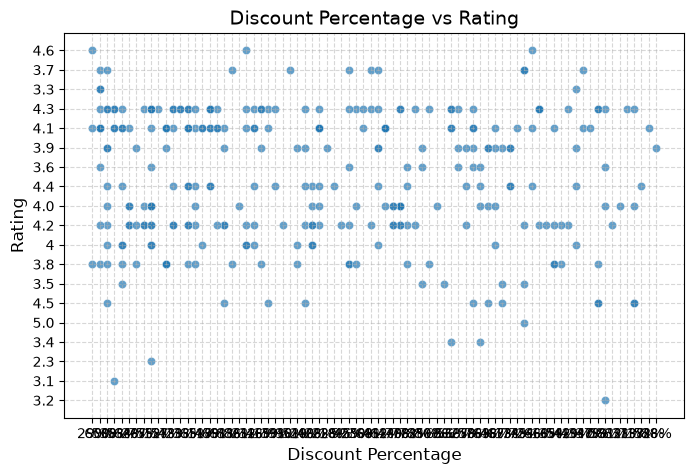

In [11]:
sample_df = df.sample(300, random_state=42)

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=sample_df,
    x="discount_percentage",
    y="rating",
    alpha=0.7
)

plt.title("Discount Percentage vs Rating", fontsize=14)
plt.xlabel("Discount Percentage", fontsize=12)
plt.ylabel("Rating", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

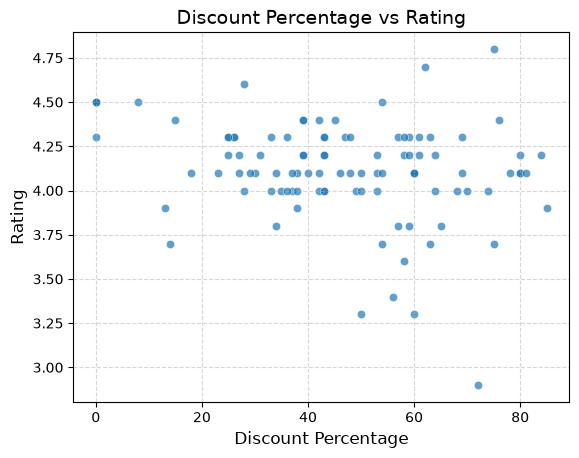

In [12]:


if "df" not in globals():
    df = pd.read_csv(
        r"C:\Users\bahga\AppData\Local\Temp\9f016490-e84a-4c0a-86e8-4578ec4b478a_amazon.csv.zip.78a\amazon.csv"
    )

sample_df = df.sample(100, random_state=30)



plot_df = sample_df.copy()
plot_df["discount_percentage"] = (
    plot_df["discount_percentage"].astype(str).str.rstrip("%").astype(float)
)
plot_df["rating"] = pd.to_numeric(plot_df["rating"], errors="coerce")

sns.scatterplot(
    data=plot_df,
    x="discount_percentage",
    y="rating",
    alpha=0.7
)

plt.title("Discount Percentage vs Rating", fontsize=14)
plt.xlabel("Discount Percentage", fontsize=12)
plt.ylabel("Rating", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

In [13]:
def create_sentiment(rating): 
    if rating >= 4:
        return 2 #Positive
    elif rating >= 3:
        return 1 #Neutral
    else:
        return 0 #Negative

In [14]:
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["sentiment"] = df["rating"].apply(create_sentiment)

print("\n===================================")
print("Sentiment Distribution")
print("===================================")

print(df["sentiment"].value_counts())

print("\nSentiment Names:")
print(
    df["sentiment"].value_counts()
    .rename(index={
        0: "Negative",
        1: "Neutral",
        2: "Positive"
    })
)
print("\n===================================")
print("Sentiment Distribution")
print("===================================")

print(df["sentiment"].value_counts())


print("\nSentiment Names:")

print(
    df["sentiment"].value_counts()
    .rename(index={
        0: "Negative",
        1: "Neutral",
        2: "Positive"
    })
)


Sentiment Distribution
sentiment
2    1110
1     348
0       7
Name: count, dtype: int64

Sentiment Names:
sentiment
Positive    1110
Neutral      348
Negative       7
Name: count, dtype: int64

Sentiment Distribution
sentiment
2    1110
1     348
0       7
Name: count, dtype: int64

Sentiment Names:
sentiment
Positive    1110
Neutral      348
Negative       7
Name: count, dtype: int64


In [15]:

df = df.dropna()
print('\nsentiment distribution:\n')
print(df['sentiment'].value_counts())


sentiment distribution:

sentiment
2    1109
1     347
0       6
Name: count, dtype: int64


In [16]:
x = df['review_content']
y = df['sentiment']

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.5, random_state=50, stratify=y)

In [21]:
# Create KNN model
knn = KNeighborsClassifier(n_neighbors=5)

# Create TF-IDF features if the TF-IDF cell has not been executed yet
if "X_train_tfidf" not in globals() or "X_test_tfidf" not in globals():
    X_train_tfidf = tfidf.fit_transform(x_train)
    X_test_tfidf = tfidf.transform(x_test)

# Train KNN
knn.fit(X_train_tfidf, y_train)

# Predict
y_pred_knn = knn.predict(X_test_tfidf)

# Accuracy
accuracy_knn = accuracy_score(y_test, y_pred_knn)

# F1 Score
f1_knn = f1_score(y_test, y_pred_knn, average='weighted')

print("KNN Accuracy:", accuracy_knn)
print("KNN F1 Score:", f1_knn)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))


KNN Accuracy: 0.7482900136798906
KNN F1 Score: 0.7232993692092016

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.47      0.28      0.35       174
           2       0.80      0.90      0.84       554

    accuracy                           0.75       731
   macro avg       0.42      0.39      0.40       731
weighted avg       0.71      0.75      0.72       731


Confusion Matrix:
[[  0   0   3]
 [  0  49 125]
 [  0  56 498]]


c:\Users\bahga\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bahga\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bahga\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [20]:
svm = SVC(kernel='linear')

# Train SVM
# Use the TF-IDF feature matrices created in the later cell
X_train = X_train_tfidf
X_test = X_test_tfidf

svm.fit(X_train, y_train)

# Predict
y_pred_svm = svm.predict(X_test)

# Evaluation
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm, average='weighted')

print("\n========== SVM ==========")
print("Accuracy:", svm_accuracy)
print("F1 Score:", svm_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))


========== SVM ==========
Accuracy: 0.7838577291381669
F1 Score: 0.7250920304704642

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.76      0.16      0.27       174
           2       0.79      0.98      0.87       554

    accuracy                           0.78       731
   macro avg       0.51      0.38      0.38       731
weighted avg       0.78      0.78      0.73       731


Confusion Matrix:
[[  0   0   3]
 [  0  28 146]
 [  0   9 545]]


c:\Users\bahga\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bahga\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bahga\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(x_train)


X_test_tfidf = tfidf.transform(x_test)

print(x_train.head())
print("\nTF-IDF Shape:")
print("Training:", X_train_tfidf.shape)
print("Testing:", X_test_tfidf.shape)

575     Product works well and charges the devices in ...
896     Single touch on off is very bad every time use...
674     Made in Indonesia, (thankfully not China).,Goo...
1248    Best,Only issue is that you might misjudge its...
404     This is good mobile stand. Sturdy with mobiles...
Name: review_content, dtype: str

TF-IDF Shape:
Training: (731, 9952)
Testing: (731, 9952)


In [23]:
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model1.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [24]:
y_pred = model1.predict(X_test_tfidf)
print("Actual values:")
print(y_test.value_counts())

print("\nPredicted values:")
print(pd.Series(y_pred).value_counts())
print("\nRating values:")
print(df["rating"].value_counts())

print("\nSentiment values:")
print(df["sentiment"].value_counts())

Actual values:
sentiment
2    554
1    174
0      3
Name: count, dtype: int64

Predicted values:
2    709
1     22
Name: count, dtype: int64

Rating values:
rating
4.1    244
4.3    230
4.2    228
4.0    181
3.9    123
4.4    123
3.8     86
4.5     75
3.7     42
3.6     35
3.5     26
4.6     17
3.3     16
3.4     10
4.7      6
3.1      4
3.0      3
4.8      3
3.2      2
5.0      2
2.8      2
2.3      1
2.0      1
2.6      1
2.9      1
Name: count, dtype: int64

Sentiment values:
sentiment
2    1109
1     347
0       6
Name: count, dtype: int64


In [25]:
accuracy = accuracy_score(y_test, y_pred)

print("\n===================================")
print("Model 1 - Logistic Regression")
print("===================================")

print("Accuracy:", round(accuracy, 4))

print("\nClassification Report:")

report = classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["Negative", "Positive"],
    zero_division=0
)

print(report)


Model 1 - Logistic Regression
Accuracy: 0.777

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         3
    Positive       0.82      0.10      0.18       174

   micro avg       0.82      0.10      0.18       177
   macro avg       0.41      0.05      0.09       177
weighted avg       0.80      0.10      0.18       177



In [26]:


label_map = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
}

y_test = y_test.map(label_map)
y_pred = pd.Series(y_pred).map(label_map)

print("y_test classes:")
print(y_test.unique())

print("\ny_pred classes:")
print(y_pred.unique())

y_test classes:
[nan]

y_pred classes:
[nan]


In [27]:

df = df.dropna()
print('\nsentiment distribution:\n')
print(df['sentiment'].value_counts())


sentiment distribution:

sentiment
2    1109
1     347
0       6
Name: count, dtype: int64



Confusion Matrix:
[[  0   0   3]
 [  0  18 156]
 [  0   4 550]]


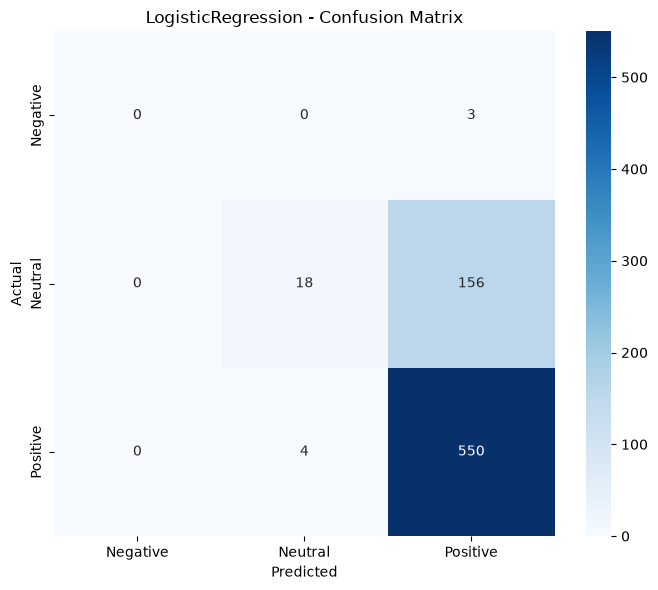

In [28]:
# Restore the original numeric labels after they were incorrectly mapped
y_test = y.loc[y_test.index].astype(int)
y_pred = pd.Series(
    model1.predict(X_test_tfidf),
    index=y_test.index
).astype(int)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
print("\nConfusion Matrix:")
print(cm)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('LogisticRegression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

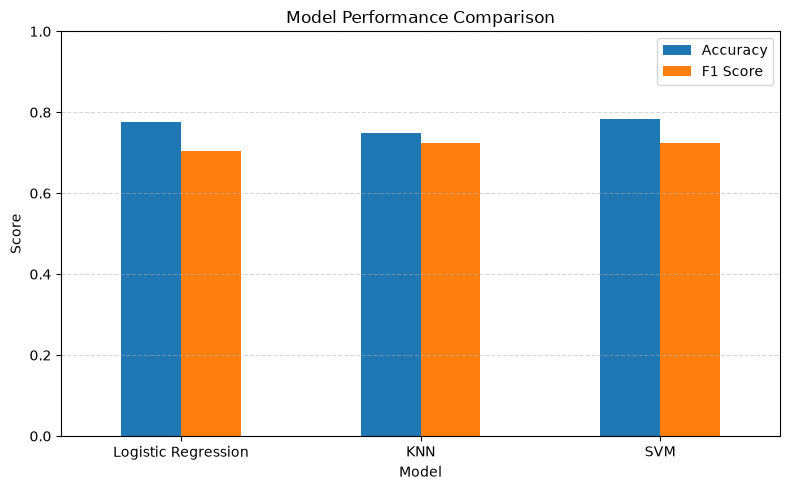

In [29]:
model_f1 = f1_score(y_test, y_pred, average="weighted")

metrics = pd.DataFrame({
    "Accuracy": [accuracy, accuracy_knn, svm_accuracy],
    "F1 Score": [model_f1, f1_knn, svm_f1]
}, index=["Logistic Regression", "KNN", "SVM"])

metrics.plot(kind="bar", figsize=(8, 5), ylim=(0, 1))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

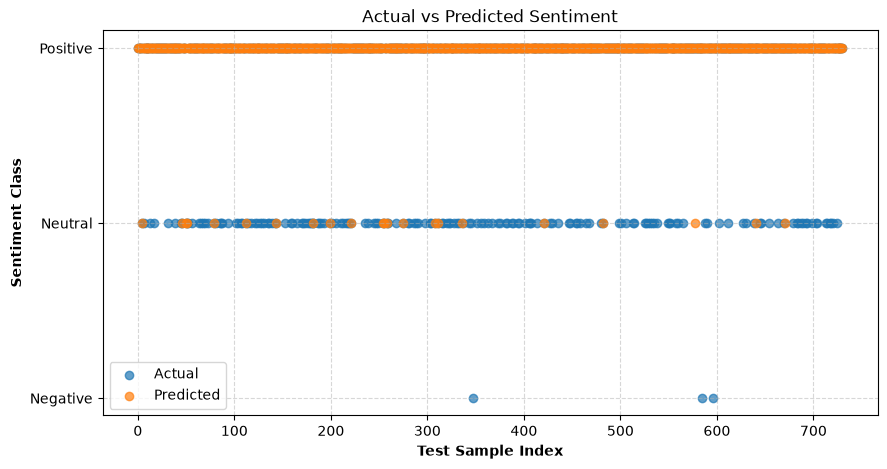

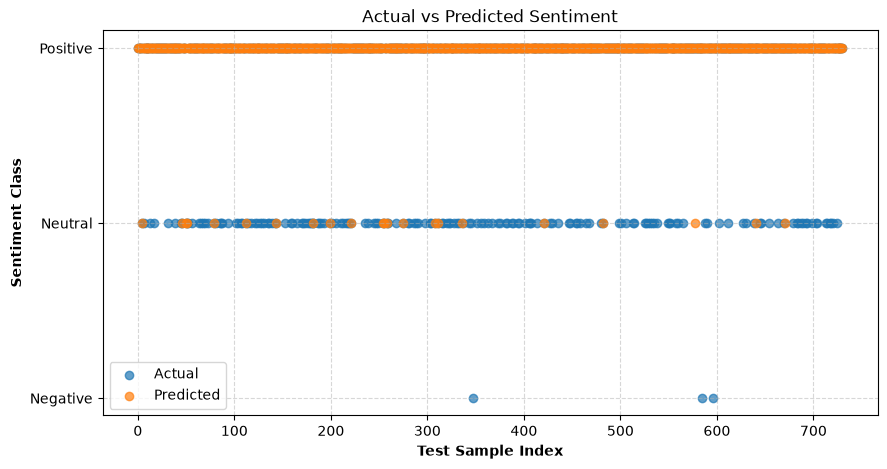

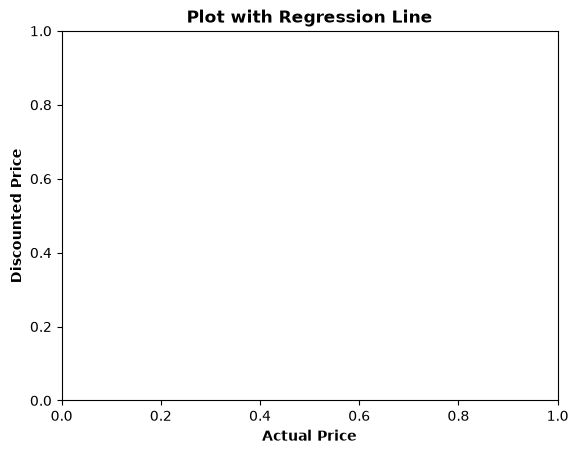

In [32]:
sample_index = np.arange(len(y_test))

plt.figure(figsize=(10, 5))
plt.scatter(sample_index, y_test.to_numpy(), label="Actual", alpha=0.7)
plt.scatter(sample_index, y_pred.to_numpy(), label="Predicted", alpha=0.7)

plt.xlabel("Test Sample Index", fontweight="bold")
plt.ylabel("Sentiment Class", fontweight="bold")
plt.title("Actual vs Predicted Sentiment")
plt.yticks([0, 1, 2], ["Negative", "Neutral", "Positive"])
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()
sample_index = np.arange(len(y_test))

plt.figure(figsize=(10, 5))

plt.scatter(
    sample_index,
    y_test.to_numpy(),
    label="Actual",
    alpha=0.7
)

plt.scatter(
    sample_index,
    y_pred.to_numpy(),
    label="Predicted",
    alpha=0.7
)

plt.xlabel("Test Sample Index", fontweight="bold")
plt.ylabel("Sentiment Class", fontweight="bold")
plt.title("Actual vs Predicted Sentiment")
plt.yticks([0, 1, 2], ["Negative", "Neutral", "Positive"])
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()
plt.xlabel('Actual Price', fontweight='bold')
plt.ylabel('Discounted Price', fontweight='bold')
plt.title('Plot with Regression Line', fontweight='bold')
plt.show()

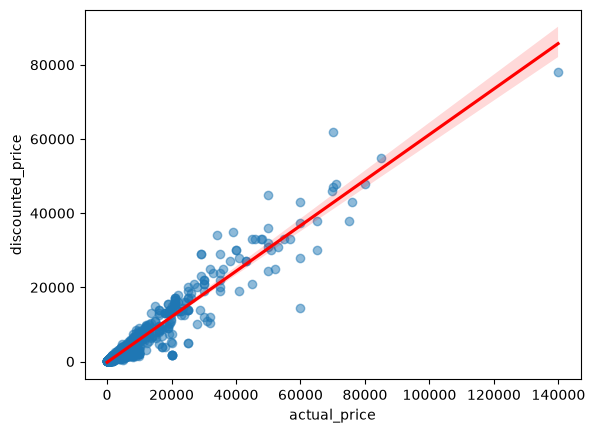

In [34]:
ols_data = df[["actual_price", "discounted_price"]].copy()

for column in ["actual_price", "discounted_price"]:
    ols_data[column] = (
        ols_data[column]
        .astype(str)
        .str.replace(r"[₹,]", "", regex=True)
        .astype(float)
    )

ols_data = ols_data.dropna()

sns.regplot(
    data=ols_data,
    x="actual_price",
    y="discounted_price",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)

plt.show()

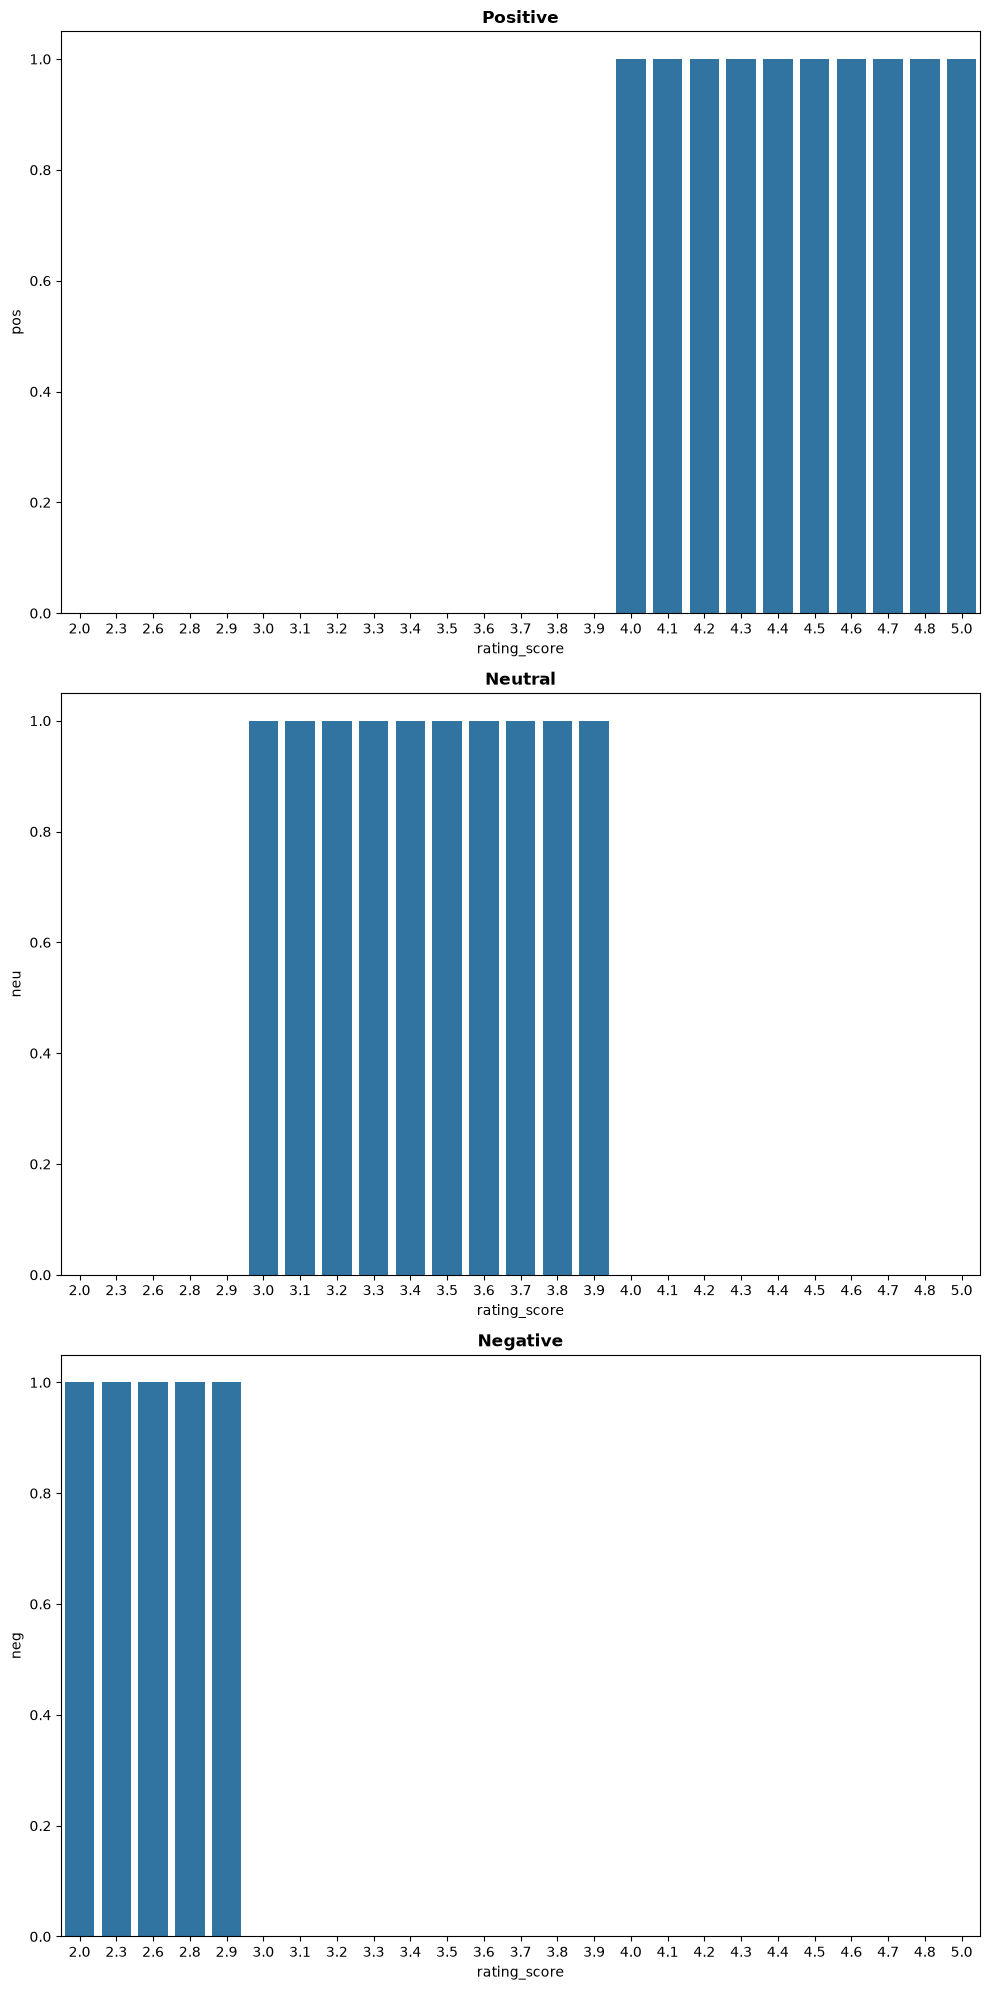

In [38]:

# Create sentiment proportions for each rating
rating_data = df.copy()
rating_data["rating_score"] = pd.to_numeric(
    rating_data["rating"], errors="coerce"
)

rating_data = rating_data.dropna(subset=["rating_score", "sentiment"])

df = pd.crosstab(
    rating_data["rating_score"],
    rating_data["sentiment"],
    normalize="index"
).reindex(columns=[2, 1, 0], fill_value=0)

df.columns = ["pos", "neu", "neg"]
df = df.reset_index()

fig, ax = plt.subplots(3, 1, figsize=(10, 20))

sns.barplot(data=df, x="rating_score", y="pos", ax=ax[0])
sns.barplot(data=df, x="rating_score", y="neu", ax=ax[1])
sns.barplot(data=df, x="rating_score", y="neg", ax=ax[2])

ax[0].set_title("Positive", fontweight="bold")
ax[1].set_title("Neutral", fontweight="bold")
ax[2].set_title("Negative", fontweight="bold")

plt.tight_layout()
plt.show()
sns.barplot(data=df, x='rating_score', y='pos', ax=ax[0])
sns.barplot(data=df, x='rating_score', y='neu', ax=ax[1])
sns.barplot(data=df, x='rating_score', y='neg', ax=ax[2])

ax[0].set_title('Positive', fontweight = 'bold')
ax[1].set_title('Neutral', fontweight = 'bold')
ax[2].set_title('Negative', fontweight = 'bold')

plt.show()